# Botnet Detection & Classification using Machine Learning

This notebook implements a **multi-class classification** pipeline that can:
1. **Detect** whether network traffic is malicious or benign
2. **Classify** the specific attack type (SYN Flood, LDAP Reflection)

**Dataset**: CIC-DDoS2019 (Parquet format)  
**Model**: Random Forest Classifier  
**Classes**: `Benign` | `Syn` | `LDAP`

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Dataset Loading & Label Normalization

We load **all four files** (SYN + LDAP, training + testing) and merge them.  
Labels are normalized since the dataset uses inconsistent names (e.g. `DrDoS_LDAP` vs `LDAP`).  

> **Why merge?** The official train/test files have inconsistent feature distributions  
> (e.g. byte-level features are zero in SYN testing but non-zero in SYN training).  
> Merging and doing a stratified split gives a much more reliable evaluation.

In [6]:
def normalize_label(label):
    label = str(label).strip().lower()
    if 'benign' in label:
        return 'Benign'
    elif 'syn' in label:
        return 'Syn'
    elif 'ldap' in label:
        return 'LDAP'
    else:
        return 'Other'


# Load ALL files
all_files = [
    'Syn-training.parquet', 'Syn-testing.parquet',
    'LDAP-training.parquet', 'LDAP-testing.parquet'
]

frames = []
for f in all_files:
    path = os.path.join('data', f)
    if os.path.exists(path):
        print(f'  Loading {f}...')
        df = pd.read_parquet(path)
        df['Label'] = df['Label'].apply(normalize_label)
        frames.append(df)

df_all = pd.concat(frames, ignore_index=True)

# Keep only target classes
TARGET_CLASSES = ['Benign', 'Syn', 'LDAP']
df_all = df_all[df_all['Label'].isin(TARGET_CLASSES)].reset_index(drop=True)

print(f'\nTotal samples: {len(df_all)}')
print(df_all['Label'].value_counts())

  Loading Syn-training.parquet...
  Loading Syn-testing.parquet...
  Loading LDAP-training.parquet...
  Loading LDAP-testing.parquet...

Total samples: 80543
Label
Syn       43835
Benign    33384
LDAP       3324
Name: count, dtype: int64


## 2. Feature Selection

From the 78 available columns, we select **22 key behavioral features** across five categories:  
Volume, Timing, Rate, Packet Statistics, and Protocol/Flags.

In [7]:
SELECTED_FEATURES = [
    # Volume
    'Total Fwd Packets', 'Total Backward Packets',
    'Fwd Packets Length Total', 'Bwd Packets Length Total',
    # Timing
    'Flow Duration', 'Flow IAT Mean', 'Flow IAT Std',
    'Fwd IAT Total', 'Bwd IAT Total',
    # Rate
    'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s',
    # Packet stats
    'Packet Length Mean', 'Packet Length Std', 'Avg Packet Size',
    # TCP Flags
    'SYN Flag Count', 'ACK Flag Count', 'RST Flag Count',
    # Protocol & Window
    'Protocol', 'Init Fwd Win Bytes', 'Down/Up Ratio',
]

available = [f for f in SELECTED_FEATURES if f in df_all.columns]
print(f'Using {len(available)} features: {available}')

Using 22 features: ['Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Flow Duration', 'Flow IAT Mean', 'Flow IAT Std', 'Fwd IAT Total', 'Bwd IAT Total', 'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Mean', 'Packet Length Std', 'Avg Packet Size', 'SYN Flag Count', 'ACK Flag Count', 'RST Flag Count', 'Protocol', 'Init Fwd Win Bytes', 'Down/Up Ratio']


## 3. Preprocessing

Handle infinities, encode labels, scale features, and perform a **stratified 80/20 split**.

In [8]:
X = df_all[available].copy()
y_raw = df_all['Label']

# Handle Infinity and NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

# Encode labels
le = LabelEncoder()
le.fit(TARGET_CLASSES)
y = le.transform(y_raw)
print(f'Label Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Stratified split (maintains class ratios in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nTraining: {X_train_scaled.shape[0]} samples')
print(f'Testing:  {X_test_scaled.shape[0]} samples')
print('\nTest set class distribution:')
for cls, idx in zip(le.classes_, range(len(le.classes_))):
    print(f'  {cls}: {(y_test == idx).sum()}')

Label Mapping: {np.str_('Benign'): np.int64(0), np.str_('LDAP'): np.int64(1), np.str_('Syn'): np.int64(2)}

Training: 64434 samples
Testing:  16109 samples

Test set class distribution:
  Benign: 6677
  LDAP: 665
  Syn: 8767


## 4. Model Training

Random Forest with 200 trees, tuned for multi-class classification.

In [9]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

print('[*] Training Random Forest (200 trees)...')
model.fit(X_train_scaled, y_train)
print('[+] Training complete.')

[*] Training Random Forest (200 trees)...
[+] Training complete.


## 5. Evaluation

Per-class precision, recall, and F1-score on the held-out test set.

In [10]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f'Overall Accuracy: {accuracy:.4f}')
print(f'\n{"="*60}')
print('Classification Report (per-class):')
print('='*60)
print(classification_report(y_test, y_pred, target_names=le.classes_))

Overall Accuracy: 0.9985

Classification Report (per-class):
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      6677
        LDAP       1.00      0.99      0.99       665
         Syn       1.00      1.00      1.00      8767

    accuracy                           1.00     16109
   macro avg       1.00      1.00      1.00     16109
weighted avg       1.00      1.00      1.00     16109



## 6. Confusion Matrix

3x3 matrix: how does the model handle each attack type?

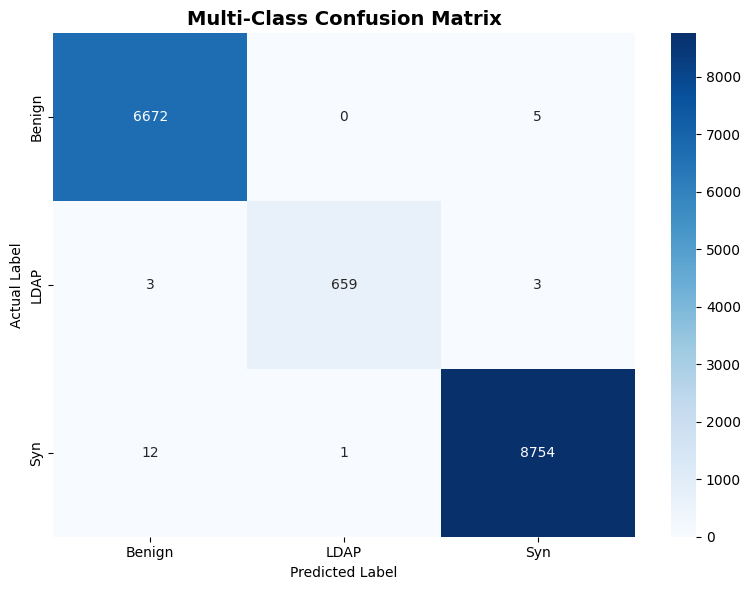

Saved to results/confusion_matrix.png


In [11]:
os.makedirs('results', exist_ok=True)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Multi-Class Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150)
plt.show()
print('Saved to results/confusion_matrix.png')

## 7. Feature Importance

Which network behaviors are most useful for distinguishing attack types?

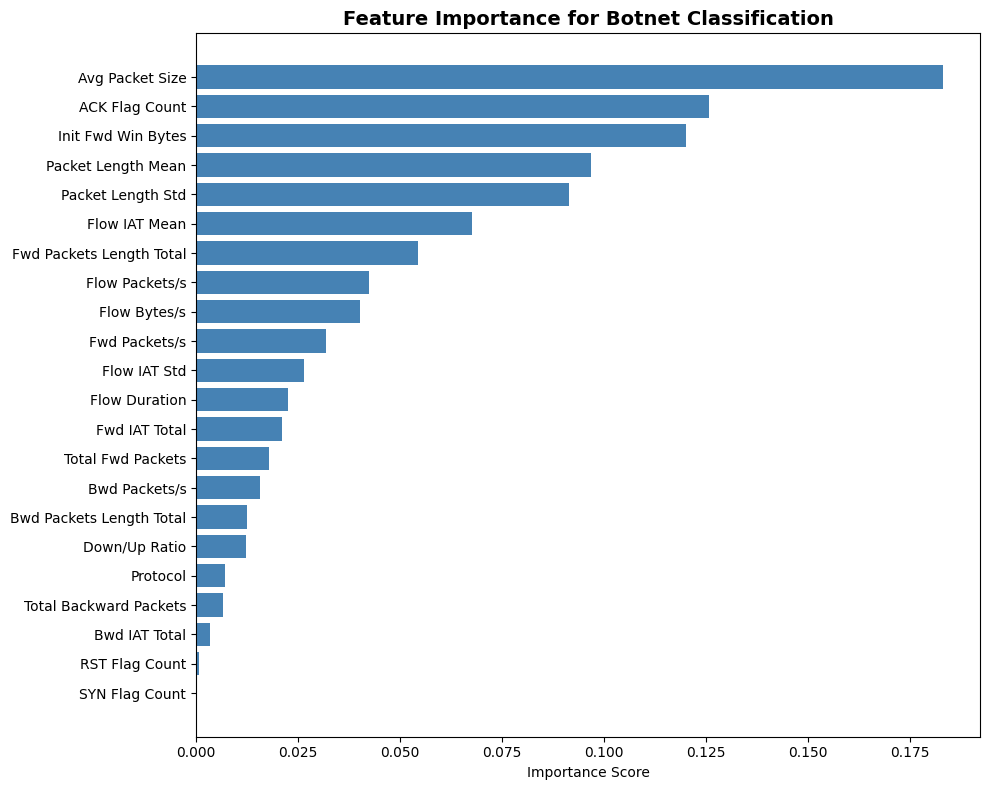


Top 5 Most Important Features:
  Avg Packet Size                     0.1830
  ACK Flag Count                      0.1257
  Init Fwd Win Bytes                  0.1200
  Packet Length Mean                  0.0967
  Packet Length Std                   0.0915


In [12]:
importances = model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': available,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
plt.title('Feature Importance for Botnet Classification', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('results/feature_importance.png', dpi=150)
plt.show()

print('\nTop 5 Most Important Features:')
for _, row in feat_imp.tail(5).iloc[::-1].iterrows():
    print(f'  {row["Feature"]:35s} {row["Importance"]:.4f}')

## 8. Save Model

Save the trained model, scaler, and label encoder for deployment.

In [13]:
import joblib

artifact = {
    'model': model,
    'scaler': scaler,
    'label_encoder': le,
    'features': available,
    'classes': list(le.classes_),
    'accuracy': accuracy
}

joblib.dump(artifact, 'results/botnet_classifier.joblib')
print(f'[+] Model saved to results/botnet_classifier.joblib')
print(f'    Classes: {list(le.classes_)}')
print(f'    Accuracy: {accuracy:.4f}')
print(f'    Features: {len(available)}')

[+] Model saved to results/botnet_classifier.joblib
    Classes: [np.str_('Benign'), np.str_('LDAP'), np.str_('Syn')]
    Accuracy: 0.9985
    Features: 22
